Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery          

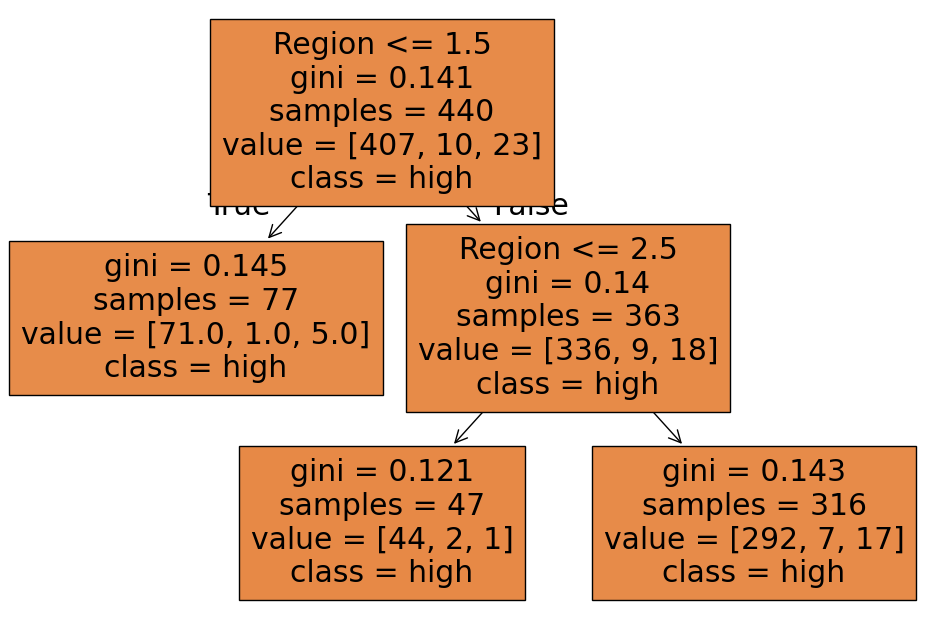

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

df = pd.read_csv('Wholesale customers data.csv')

print(df.columns)

print(df.head())
print(df.info())
print(df.describe())

spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df['total_spending'] = df[spending_cols].sum(axis=1)

df['revenue_category'] = pd.cut(df['total_spending'],
                                bins=[0, 5000, 10000, float('inf')],
                                labels=['low', 'medium', 'high'])


X = df[['Region']]

X = pd.get_dummies(X, drop_first=True)

Y = df['revenue_category']

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, Y)

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=clf.classes_)
plt.show()

Decision Tree Classifier Performance:
              precision    recall  f1-score   support

        high       0.94      1.00      0.97        83
         low       0.00      0.00      0.00         3
      medium       0.00      0.00      0.00         2

    accuracy                           0.94        88
   macro avg       0.31      0.33      0.32        88
weighted avg       0.89      0.94      0.92        88



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


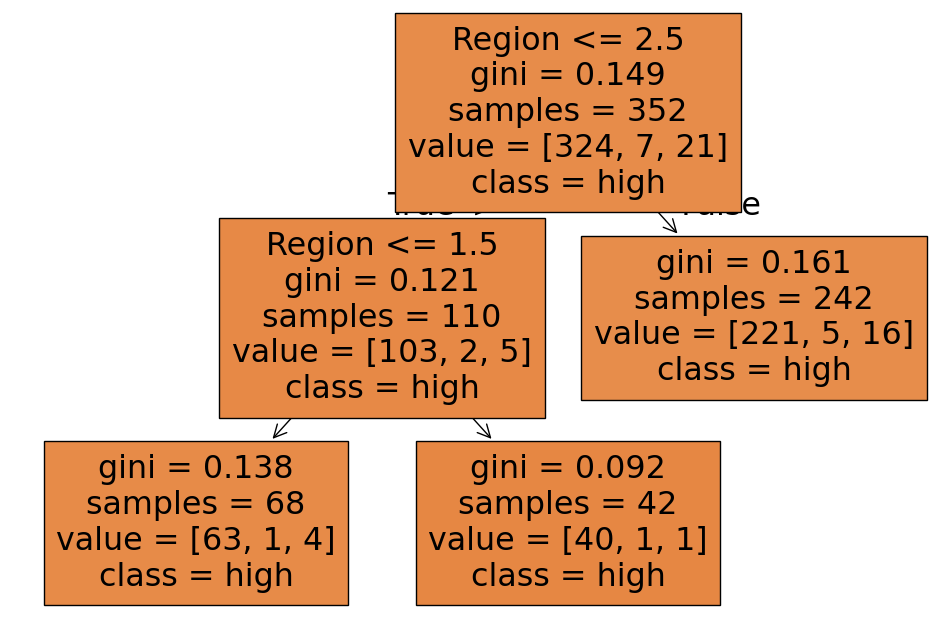

Support Vector Machine (SVM) Performance:
              precision    recall  f1-score   support

        high       0.94      1.00      0.97        83
         low       0.00      0.00      0.00         3
      medium       0.00      0.00      0.00         2

    accuracy                           0.94        88
   macro avg       0.31      0.33      0.32        88
weighted avg       0.89      0.94      0.92        88



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv('Wholesale customers data.csv')

spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df['total_spending'] = df[spending_cols].sum(axis=1)

df['revenue_category'] = pd.cut(df['total_spending'],
                                bins=[0, 5000, 10000, float('inf')],
                                labels=['low', 'medium', 'high'])

X = pd.get_dummies(df[['Region']], drop_first=True)
y = df['revenue_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_tree = DecisionTreeClassifier(random_state=42)
clf_tree.fit(X_train, y_train)
y_pred_tree = clf_tree.predict(X_test)

print("Decision Tree Classifier Performance:")
print(classification_report(y_test, y_pred_tree))

plt.figure(figsize=(12,8))
plot_tree(clf_tree, filled=True, feature_names=X.columns, class_names=clf_tree.classes_)
plt.show()

clf_svm = SVC(kernel='linear', random_state=42)
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)

print("Support Vector Machine (SVM) Performance:")
print(classification_report(y_test, y_pred_svm))
